# Assignment 1
This notebook contains the solution for all exercises.

# 1. Coordinate Descent

In [73]:
def argmin_x1(x):
    return (2*x[2]+3*x[1]-1)/2

def argmin_x2(x):
    return (2*x[2]+x[0]+5)/6

def argmin_x3(x):
    return (3*x[1]-4+x[0])/4

def f(x):
    return (np.exp(x[0]-3*x[1]+3)+np.exp(3*x[1]-2*x[2]-2)+np.exp(2*x[2]-x[0]+2))

def coordinate_descent(f, argmin, x0, max_iter=100, verbose=False):
    x = x0.copy()
    for i in range(max_iter):
      # update best new values for x1, x2, x3 respectively.
        x[0] = argmin[0](x)
        x[1] = argmin[1](x)
        x[2] = argmin[2](x)
    return x

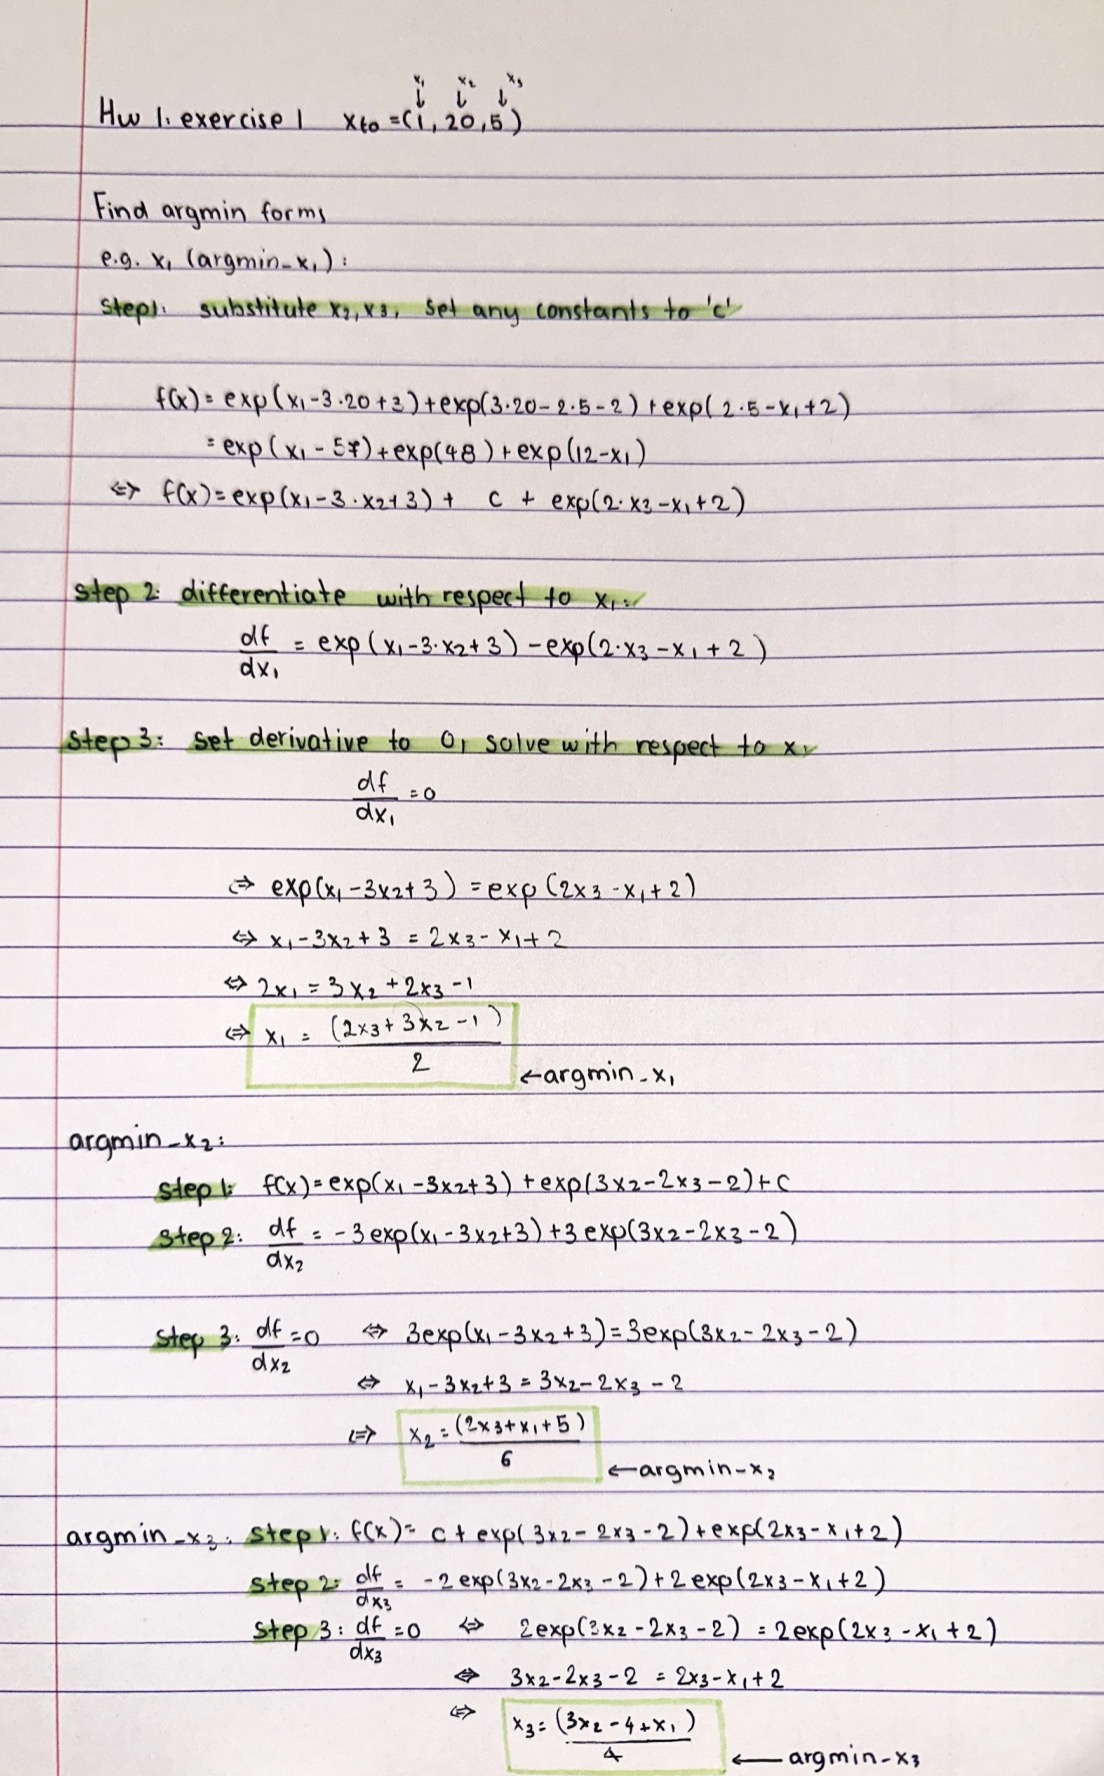

In [74]:
from IPython.display import Image
Image('./explanations/Hw1_ex1.jpg', width=500)

In [75]:
import numpy as np

x0 = np.array([1.0, 20.0, 5.0])
argmin = [argmin_x1, argmin_x2, argmin_x3]

# results for execise 1
result = coordinate_descent(f, argmin, x0, max_iter=25)
print("x1 =", result[0])
print("x2 =", result[1])
print("x3 =", result[2])
print("f(x*) =", f(result))

print()

# prints every iteration of f(x)
x = x0.copy()
for i in range(25):
    x[0] = argmin_x1(x)
    x[1] = argmin_x2(x)
    x[2] = argmin_x3(x)
    print(f"t={i+1}: f(x) = {f(x)}")

x1 = 26.666666666666664
x2 = 9.555555555555555
x3 = 12.833333333333332
f(x*) = 8.154845485377136

t=1: f(x) = 344551.91140801215
t=2: f(x) = 11.956555671423452
t=3: f(x) = 8.225815699707024
t=4: f(x) = 8.155915135012185
t=5: f(x) = 8.154862270301798
t=6: f(x) = 8.154845747500453
t=7: f(x) = 8.154845489473088
t=8: f(x) = 8.154845485441134
t=9: f(x) = 8.154845485378136
t=10: f(x) = 8.154845485377152
t=11: f(x) = 8.154845485377137
t=12: f(x) = 8.154845485377136
t=13: f(x) = 8.154845485377136
t=14: f(x) = 8.154845485377136
t=15: f(x) = 8.154845485377136
t=16: f(x) = 8.154845485377136
t=17: f(x) = 8.154845485377136
t=18: f(x) = 8.154845485377136
t=19: f(x) = 8.154845485377136
t=20: f(x) = 8.154845485377136
t=21: f(x) = 8.154845485377136
t=22: f(x) = 8.154845485377136
t=23: f(x) = 8.154845485377136
t=24: f(x) = 8.154845485377136
t=25: f(x) = 8.154845485377136


# 2. Gradient Descent

In [76]:
import numpy as np

#Himmelblau's Function and Gradient
def f(u, v):
    return (u**2 + v - 11)**2 + (u + v**2 - 7)**2

def grad_f(u, v):
    du = 4 * u * (u**2 + v - 11) + 2 * (u + v**2 - 7)
    dv = 2 * (u**2 + v - 11) + 4 * v * (u + v**2 - 7)
    return np.array([du, dv])

#Core Gradient Descent Optimization Loop
def gradient_descent(eta, u0, v0, max_iter=100):
    u, v = u0, v0
    values = [f(u, v)]

    for t in range(1, max_iter + 1):
        g = grad_f(u, v)
        step_size = eta(t) #Get step size for the current iteration

        #Update rule
        u = u - step_size * g[0]
        v = v - step_size * g[1]

        values.append(f(u, v))

    return u, v, values[-1], min(values)

#Calculations for Questions 2a, 2b, 2c, 2d
print("=== 2a: Constant Step Size ===")
eta_const = lambda t: 1e-3
_, _, final_2a, best_2a = gradient_descent(eta_const, u0=4, v0=-5)
print(f"Final Val: {final_2a:.4f}")
print(f"Best Val: {best_2a:.4f}\n")


print("=== 2b: Decreasing Step Size (Inverse Square Root) ===")
eta_sqrt = lambda t: 1e-3 / np.sqrt(t + 1)
_, _, final_2b, best_2b = gradient_descent(eta_sqrt, u0=4, v0=-5)
print(f"Final Val: {final_2b:.4f}")
print(f"Best Val: {best_2b:.4f}\n")


print("=== 2c: Multi-Step Schedule ===")
def eta_multistep(t, milestones=[30, 80, 100], c=1e-3, eta_init=1e-3):
    drops = sum(1 for m in milestones if t >= m)
    return eta_init * (c ** drops)
_, _, final_2c, best_2c = gradient_descent(eta_multistep, u0=4, v0=-5)
print(f"Final Val: {final_2c:.4f}")
print(f"Best Val: {best_2c:.4f}\n")


print("=== 2d: Initialization ===")
start_points = {
    "p1": (-4, 0),
    "p2": (0, 0),
    "p3": (4, 0),
    "p4": (0, 4),
    "p5": (5, 5)
}

for p_name, (u0, v0) in start_points.items():
    uf, vf, final_f, _ = gradient_descent(eta_const, u0, v0)
    print(f"{p_name} final point: ({uf:.4f}, {vf:.4f})")
    print(f"{p_name} final val: {final_f:.4f}")
    print("-" * 25)

=== 2a: Constant Step Size ===
Final Val: 0.0289
Best Val: 0.0289

=== 2b: Decreasing Step Size (Inverse Square Root) ===
Final Val: 14.4814
Best Val: 14.4814

=== 2c: Multi-Step Schedule ===
Final Val: 4.0342
Best Val: 4.0342

=== 2d: Initialization ===
p1 final point: (-3.1528, -0.7246)
p1 final val: 95.8785
-------------------------
p2 final point: (2.9086, 2.0931)
p2 final val: 0.2836
-------------------------
p3 final point: (3.4504, -0.4817)
p3 final val: 11.1859
-------------------------
p4 final point: (-2.3671, 3.1000)
p4 final val: 5.3342
-------------------------
p5 final point: (2.9822, 2.0414)
p5 final val: 0.0266
-------------------------


# 3. Polynomial Regression

In [77]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
# The description of this dataset applies to the data provided over Canvas
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [78]:
import pandas as pd

# Adapt path
df = pd.read_csv("california_housing_with_split.csv")

train = df[df["split"] == "train"]
test  = df[df["split"] == "test"]

X_train = train.drop(columns=["MedHouseVal", "split"])
y_train = train["MedHouseVal"]

X_test = test.drop(columns=["MedHouseVal", "split"])
y_test = test["MedHouseVal"]

In [79]:
# standardization

from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

In [80]:
# 3a linear model

from sklearn.linear_model import LinearRegression
from IPython.display import display, Math
from sklearn.metrics import mean_squared_error

feature_names = X_train.columns

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)
mse_linear_model = mean_squared_error(y_test, y_pred_linear)

linear_model_coef = dict(zip(feature_names, linear_model.coef_))

print("Linear model metrics:")
display(Math(f"\\beta_{{\\text{{MedInc}}}} = {linear_model_coef['MedInc']:.6f}"))
display(Math(f"\\beta_{{\\text{{AveBedrms}}}} = {linear_model_coef['AveBedrms']:.6f}"))
display(Math(f"\\beta_{{\\text{{HouseAge}}}} = {linear_model_coef['HouseAge']:.6f}"))
display(Math(f"\\text{{MSE}}_{{\\text{{test}}}} = {mse_linear_model:.6f}"))

Linear model metrics:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [81]:
# 3a polynomial model

from sklearn.preprocessing import PolynomialFeatures

polynomial_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = polynomial_features.fit_transform(X_train_scaled)
X_test_poly = polynomial_features.transform(X_test_scaled)

polynomial_model = LinearRegression()
polynomial_model.fit(X_train_poly, y_train)

y_pred_poly = polynomial_model.predict(X_test_poly)
mse_poly_model = mean_squared_error(y_test, y_pred_poly)

polynomial_feature_names = polynomial_features.get_feature_names_out(feature_names)
poly_model_coef = dict(zip(polynomial_feature_names, polynomial_model.coef_))

print("Polynomial model metrics:")
display(Math(f"\\beta_{{\\text{{MedInc}}}} = {poly_model_coef['MedInc']:.6f}"))
display(Math(f"\\beta_{{\\text{{MedInc}} \\cdot \\text{{AveBedrms}}}} = {poly_model_coef['MedInc AveBedrms']:.6f}"))
display(Math(f"\\beta_{{\\text{{HouseAge}} \\cdot \\text{{AveBedrms}}}} = {poly_model_coef['HouseAge AveBedrms']:.6f}"))
display(Math(f"\\text{{MSE}}_{{\\text{{test}}}} = {mse_poly_model:.6f}"))

Polynomial model metrics:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [82]:
# 3b ridge model

from sklearn.linear_model import Ridge

# objective is min (1/n) * ||y - Xb||^2 + lambda * ||b||^2 <=> min ||y - Xb||^2 + n * lambda * ||b||^2
# min b does not change if we multiply the objective by n

n_train_samples = X_train_poly.shape[0]
lambdaa = 0.001

# from https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
# ||y - Xw||^2 + alpha * ||w||^2
alpha = lambdaa * n_train_samples

ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train_poly, y_train)

y_pred_ridge = ridge_model.predict(X_test_poly)
mse_ridge_model = mean_squared_error(y_test, y_pred_ridge)

ridge_model_coef = dict(zip(polynomial_feature_names, ridge_model.coef_))

print("Ridge model metrics:")
display(Math(f"\\beta_{{\\text{{MedInc}}}} = {ridge_model_coef['MedInc']:.6f}"))
display(Math(f"\\beta_{{\\text{{MedInc}} \\cdot \\text{{AveBedrms}}}} = {ridge_model_coef['MedInc AveBedrms']:.6f}"))
display(Math(f"\\beta_{{\\text{{HouseAge}} \\cdot \\text{{AveBedrms}}}} = {ridge_model_coef['HouseAge AveBedrms']:.6f}"))
display(Math(f"\\text{{MSE}}_{{\\text{{test}}}} = {mse_ridge_model:.6f}"))

Ridge model metrics:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# 4. Naive Bayes

In [83]:
from sklearn.datasets import fetch_20newsgroups
categories = ['sci.space', 'misc.forsale', 'comp.graphics', 'rec.sport.hockey']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

print(train.DESCR)

.. _20newsgroups_dataset:

The 20 newsgroups text dataset
------------------------------

The 20 newsgroups dataset comprises around 18000 newsgroups posts on
20 topics split in two subsets: one for training (or development)
and the other one for testing (or for performance evaluation). The split
between the train and test set is based upon a messages posted before
and after a specific date.

This module contains two loaders. The first one,
:func:`sklearn.datasets.fetch_20newsgroups`,
returns a list of the raw texts that can be fed to text feature
extractors such as :class:`~sklearn.feature_extraction.text.CountVectorizer`
with custom parameters so as to extract feature vectors.
The second one, :func:`sklearn.datasets.fetch_20newsgroups_vectorized`,
returns ready-to-use features, i.e., it is not necessary to use a feature
extractor.

**Data Set Characteristics:**

=================   ==========
Classes                     20
Samples total            18846
Dimensionality               1

In [84]:
# NOTE: inconsistency with notebook class ordering and ANS's table on question 4.
# I chose the ordering from Ans, as I believe this aligns better with the assignment

In [85]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

alpha = 1e-5

categories = ['sci.space', 'misc.forsale', 'comp.graphics', 'rec.sport.hockey']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

vectorizer = CountVectorizer(stop_words="english", min_df=5, token_pattern=r"[^\W\d_]+", binary=True)
D = vectorizer.fit_transform(train.data)
y_train = train.target

# build df
df = pd.DataFrame(D.toarray(), columns=vectorizer.get_feature_names_out())
df['class'] = y_train
df['class_name'] = [train.target_names[i] for i in y_train]

d = D.shape[1]

class_order = ['sci.space', 'misc.forsale', 'comp.graphics', 'rec.sport.hockey']

results = []
for c, name in enumerate(class_order):
    count = df[df['class_name'] == name]['chip'].sum()
    n_class = df[df['class_name'] == name]['chip'].count()
    log_prob = np.log((count + alpha) / (n_class + alpha * d))
    results.append({
        'y': c,
        'class_name': name,
        'chip_count': count,
        'n_class': n_class,
        'log p(chip=1|y)': log_prob
    })

pd.DataFrame(results)

,y,class_name,chip_count,n_class,log p(chip=1|y)
0,0,sci.space,1,593,-6.385309
1,1,misc.forsale,10,585,-4.069152
2,2,comp.graphics,9,584,-4.172802
3,3,rec.sport.hockey,6,600,-4.605292


In [86]:
summary = pd.DataFrame({
    'chip_count': df.groupby('class_name')['chip'].sum(),
    'n_class': df.groupby('class_name')['chip'].count(),
    'd': D.shape[1]
})

summary

,chip_count,n_class,d
class_name,,,
comp.graphics,9,584,7386
misc.forsale,10,585,7386
rec.sport.hockey,6,600,7386
sci.space,1,593,7386


In [87]:
# NOTE: notebook ordering
print(train.target_names)

['comp.graphics', 'misc.forsale', 'rec.sport.hockey', 'sci.space']


In [88]:
# ansswer for 4b and
alpha = 1e-5
d = D.shape[1]
total_docs = len(y_train)
words = ['electronics', 'sale', 'games', 'ball']

# assignment ordering
class_order = ['sci.space', 'misc.forsale', 'comp.graphics', 'rec.sport.hockey']

for c, word in enumerate(words):
    counts = df.groupby('class_name')[word].sum()
    n_class = df.groupby('class_name')[word].count()

    # p(word|y=k) for all classes
    p_word_given_y = (counts + alpha) / (n_class + alpha * d)

    # p(y=k) priors
    p_y = n_class / total_docs

    # numerators
    numerators = p_word_given_y * p_y

    # normalize
    p_y_given_word = numerators / numerators.sum()

    # print result for the target class
    alpha = 1e-5
d = D.shape[1]
total_docs = len(y_train)

word_class_pairs = [
    ('electronics', 'sci.space'),
    ('sale', 'misc.forsale'),
    ('games', 'comp.graphics'),
    ('ball', 'rec.sport.hockey')
]

for c, (word, target_class) in enumerate(word_class_pairs):
    counts = df.groupby('class_name')[word].sum()
    n_class = df.groupby('class_name')[word].count()
    p_word_given_y = (counts + alpha) / (n_class + alpha * d)
    p_y = n_class / total_docs
    numerators = p_word_given_y * p_y
    p_y_given_word = numerators / numerators.sum()
    print(f"p(y={c} | x_{word}=1) = {p_y_given_word[target_class]:.6f}")

p(y=0 | x_electronics=1) = 0.315790
p(y=1 | x_sale=1) = 0.957333
p(y=2 | x_games=1) = 0.029703
p(y=3 | x_ball=1) = 0.333334


The classes are indicated categorically with indices from zero to two by the target vector. The target names tell us which index belongs to which class.

In [89]:
y_train = train.target
y_train

array([3, 3, 1, ..., 2, 1, 0], shape=(2362,))

In [90]:
train.target_names

['comp.graphics', 'misc.forsale', 'rec.sport.hockey', 'sci.space']

We represent the documents in a bag of word format. That is, we create a data matrix ``D`` such that ``D[j,i]=1`` if the j-th document contains the i-th feature (word), and ``D[j,i]=0`` otherwise.

In [91]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
vectorizer = CountVectorizer(stop_words="english", min_df=5,token_pattern=r"[^\W\d_]+", binary=True)
D = vectorizer.fit_transform(train.data)
D_test = vectorizer.transform(test.data)

We get the allocation of feature indices to words by the following array, containing the vocabulary.

In [92]:
vectorizer.get_feature_names_out()

array(['aa', 'aargh', 'ab', ..., 'zubov', 'zv', 'zyeh'],
      shape=(7386,), dtype=object)

For example, the word `zubov` has the index 7383.

In [93]:
np.where(vectorizer.get_feature_names_out() == 'zubov')[0]

array([7383])

# 5. Decision Trees

In [94]:
import pandas as pd
import numpy as np

#Load Titanic dataset
df = pd.read_csv("train.csv")

def gini_impurity(y):
    """Calculates Gini Impurity of a binary target array."""
    if len(y) == 0:
        return 0
    p1 = np.sum(y) / len(y)
    p0 = 1 - p1
    return 1 - (p0**2 + p1**2)

def information_gain(df, feature, split_val, is_continuous):
    """Computes Information Gain for a given split point."""
    #Compute IG only on observed values
    valid_data = df.dropna(subset=[feature, 'Survived'])
    y_full = valid_data['Survived'].values

    H_parent = gini_impurity(y_full)
    n = len(y_full)

    #Apply split condition
    if is_continuous:
        left_mask = valid_data[feature] >= split_val
    else:
        left_mask = valid_data[feature] == split_val

    y_left = y_full[left_mask]
    y_right = y_full[~left_mask]

    #Calculate weighted impurity of children
    H_left = gini_impurity(y_left)
    H_right = gini_impurity(y_right)
    H_child = (len(y_left) / n) * H_left + (len(y_right) / n) * H_right

    return H_parent - H_child

def evaluate_splits_for_feature(df, feature, is_continuous):
    """Finds the best split value and highest Information Gain for a feature."""
    valid_data = df.dropna(subset=[feature])
    unique_vals = np.sort(valid_data[feature].unique())

    best_ig = -1
    best_split = None

    #Define possible split points
    if is_continuous:
        #Midpoints between consecutive values
        split_points = (unique_vals[:-1] + unique_vals[1:]) / 2
    else:
        #Unique discrete values
        split_points = unique_vals

    for val in split_points:
        ig = information_gain(df, feature, val, is_continuous)
        if ig > best_ig:
            best_ig = ig
            best_split = val

    return best_split, best_ig

#Execution
#Define variable types
features = {
    'Sex': False,
    'Pclass': False,
    'Embarked': False,
    'Fare': True,
    'Age': True
}

#Store results
results = {}
for feat, is_cont in features.items():
    best_split, best_ig = evaluate_splits_for_feature(df, feat, is_cont)
    results[feat] = {'split': best_split, 'ig': best_ig}

#Print the exact text from the PDF with filled-in answers
print("=== Exercise 5 Answers ===")
print(f"The root split on Sex has IG={results['Sex']['ig']:.4f}")
print(f"The best root split on Pclass is Pclass = {results['Pclass']['split']} and has IG={results['Pclass']['ig']:.4f}")
print(f"The best root split on Fare is Fare >= {results['Fare']['split']:.4f} and has IG={results['Fare']['ig']:.4f}")
print(f"The best root split on Age is Age >= {results['Age']['split']:.4f} and has IG={results['Age']['ig']:.4f}")
print(f"The best root split on Embarked is Embarked = {results['Embarked']['split']} and has IG={results['Embarked']['ig']:.4f}")

=== Exercise 5 Answers ===
The root split on Sex has IG=0.1396
The best root split on Pclass is Pclass = 3 and has IG=0.0491
The best root split on Fare is Fare >= 10.4812 and has IG=0.0426
The best root split on Age is Age >= 6.5000 and has IG=0.0123
The best root split on Embarked is Embarked = C and has IG=0.0136


#6. Lasso vs Ridge Regression

In [95]:
# load data

import pandas as pd
df = pd.read_csv("METABRIC_RNA_Mutation.csv")
df_D = pd.concat([df['age_at_diagnosis'], df.iloc[:, 31:520]],axis=1)
D = df_D.to_numpy()
y = df['overall_survival_months'].to_numpy()

/var/folders/j7/5c4q135n1d7848nc4qdb9q5h0000gn/T/ipykernel_14166/3110539904.py:4: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [96]:
import numpy as np

n, p = D.shape
X = np.column_stack((np.ones(n), D))
print(p)
X.shape

490


(1904, 491)

In [97]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler


#\beta = (X^T X + 2n\lambda L)^{-1} X^T y
# def fit_ridge_model(X, y, lambdaa):
#     p = X.shape[1]
#     I = np.eye(p)
#     I[0, 0] = 0
#     return np.linalg.pinv(X.T @ X + 2 * n * lambdaa * I) @ X.T @ y

def fit_ridge_model(X, y, lambdaa):
    penalty = np.eye(X.shape[1])
    penalty[0, 0] = 0
    A = X.T @ X + 2 * X.shape[0] * lambdaa * penalty
    b = X.T @ y
    return np.linalg.solve(A, b)

kf = KFold(n_splits=5, shuffle=True, random_state=69)
lambdas = np.logspace(-10, np.log10(8), 20)
lambdas_desc = lambdas[::-1]

ridge_train_sums = np.zeros(len(lambdas))
ridge_test_sums = np.zeros(len(lambdas))
ridge_feature_sums = np.zeros(len(lambdas))
lasso_train_sums = np.zeros(len(lambdas))
lasso_test_sums = np.zeros(len(lambdas))
lasso_feature_sums = np.zeros(len(lambdas))

for train_idx, test_idx in kf.split(D):
    D_train = D[train_idx]
    D_test = D[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    scaler = StandardScaler()
    D_train_scaled = scaler.fit_transform(D_train)
    D_test_scaled = scaler.transform(D_test)

    X_train = np.column_stack((np.ones(len(train_idx)), D_train_scaled))
    X_test = np.column_stack((np.ones(len(test_idx)), D_test_scaled))

    for i, lambdaa in enumerate(lambdas):
        beta_ridge = fit_ridge_model(X_train, y_train, lambdaa)

        # predict ridge model
        y_pred_ridge_train = X_train @ beta_ridge
        y_pred_ridge_test = X_test @ beta_ridge

        ridge_train_sums[i] += mean_squared_error(y_train, y_pred_ridge_train)
        ridge_test_sums[i] += mean_squared_error(y_test, y_pred_ridge_test)
        ridge_feature_sums[i] += np.sum(np.abs(beta_ridge[1:]) > 1e-16)

    lasso = Lasso(alpha=lambdas_desc[0], fit_intercept=True, warm_start=True, max_iter=50000)
    fold_lasso_train = np.zeros(len(lambdas_desc))
    fold_lasso_test = np.zeros(len(lambdas_desc))
    fold_lasso_features = np.zeros(len(lambdas_desc))

    for j, lambdaa in enumerate(lambdas_desc):
        lasso.alpha = lambdaa
        lasso.fit(D_train_scaled, y_train)

        y_pred_lasso_train = lasso.predict(D_train_scaled)
        y_pred_lasso_test = lasso.predict(D_test_scaled)

        fold_lasso_train[j] = mean_squared_error(y_train, y_pred_lasso_train)
        fold_lasso_test[j] = mean_squared_error(y_test, y_pred_lasso_test)
        fold_lasso_features[j] = np.sum(np.abs(lasso.coef_) > 1e-16)

    lasso_train_sums += fold_lasso_train[::-1]
    lasso_test_sums += fold_lasso_test[::-1]
    lasso_feature_sums += fold_lasso_features[::-1]

all_df = pd.DataFrame(
    {
        "lambda": lambdas,
        "ridge_train_mse": ridge_train_sums / 5,
        "ridge_test_mse": ridge_test_sums / 5,
        "ridge_features": ridge_feature_sums / 5,
        "lasso_train_mse": lasso_train_sums / 5,
        "lasso_test_mse": lasso_test_sums / 5,
        "lasso_features": lasso_feature_sums / 5,
    }
)

In [98]:
all_df.head()

,lambda,ridge_train_mse,ridge_test_mse,ridge_features,lasso_train_mse,lasso_test_mse,lasso_features
0,1.000000e-10,3247.440039,7441.679542,490.0,3247.440039,7441.679548,490.0
1,3.748408e-10,3247.440039,7441.679523,490.0,3247.440039,7441.679547,490.0
2,1.405056e-09,3247.440039,7441.679452,490.0,3247.440039,7441.679540,490.0
3,5.266724e-09,3247.440039,7441.679184,490.0,3247.440039,7441.679513,490.0
4,1.974183e-08,3247.440039,7441.678180,490.0,3247.440039,7441.679414,490.0


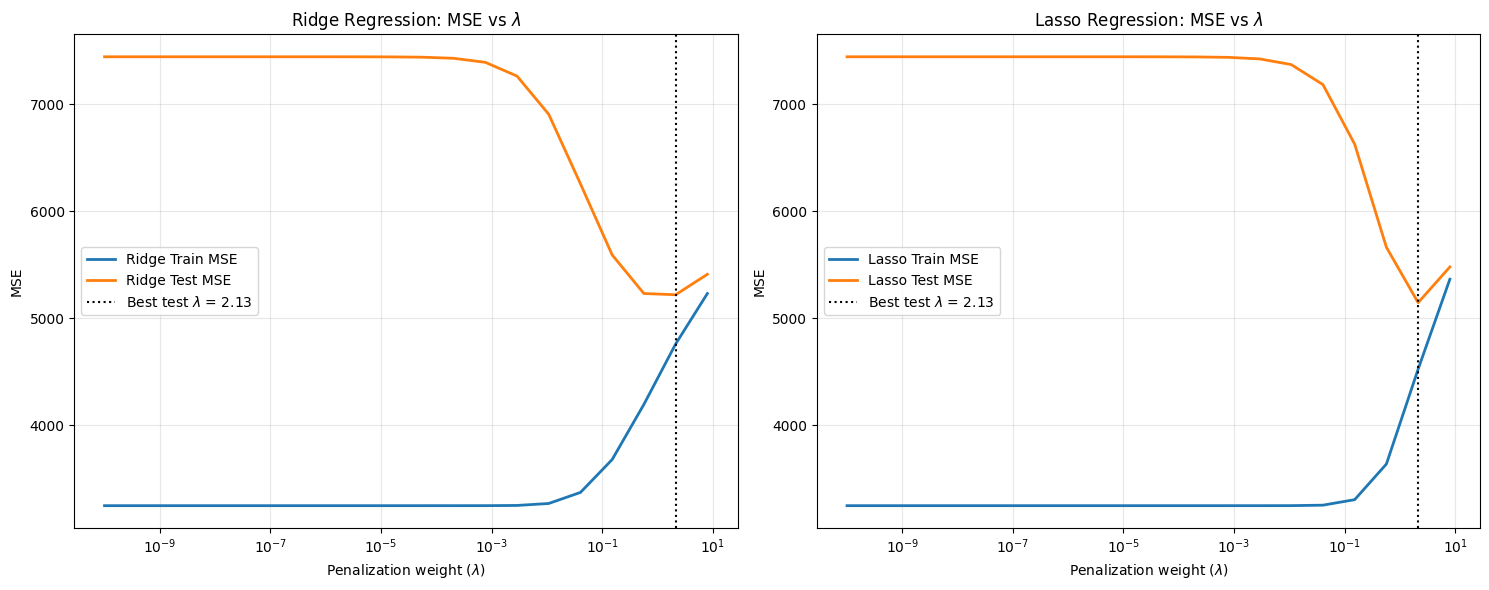

In [99]:
# 6a plot

import matplotlib.pyplot as plt

best_test_lambda_ridge = all_df.loc[all_df["ridge_test_mse"].idxmin(), "lambda"]
best_test_lambda_lasso = all_df.loc[all_df["lasso_test_mse"].idxmin(), "lambda"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(all_df["lambda"], all_df["ridge_train_mse"], label="Ridge Train MSE", lw=2)
axes[0].plot(all_df["lambda"], all_df["ridge_test_mse"], label="Ridge Test MSE", lw=2)
axes[0].axvline(best_test_lambda_ridge, color="black", linestyle=":", label=rf"Best test $\lambda$ = {best_test_lambda_ridge:.3g}")
axes[0].set_xscale("log")
axes[0].set_title(r"Ridge Regression: MSE vs $\lambda$")
axes[0].set_xlabel(r"Penalization weight ($\lambda$)")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_df["lambda"], all_df["lasso_train_mse"], label="Lasso Train MSE", lw=2)
axes[1].plot(all_df["lambda"], all_df["lasso_test_mse"], label="Lasso Test MSE", lw=2)
axes[1].axvline(best_test_lambda_lasso, color="black", linestyle=":", label=rf"Best test $\lambda$ = {best_test_lambda_lasso:.3g}")
axes[1].set_xscale("log")
axes[1].set_title(r"Lasso Regression: MSE vs $\lambda$")
axes[1].set_xlabel(r"Penalization weight ($\lambda$)")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig("q6a.png", dpi=200, bbox_inches="tight")

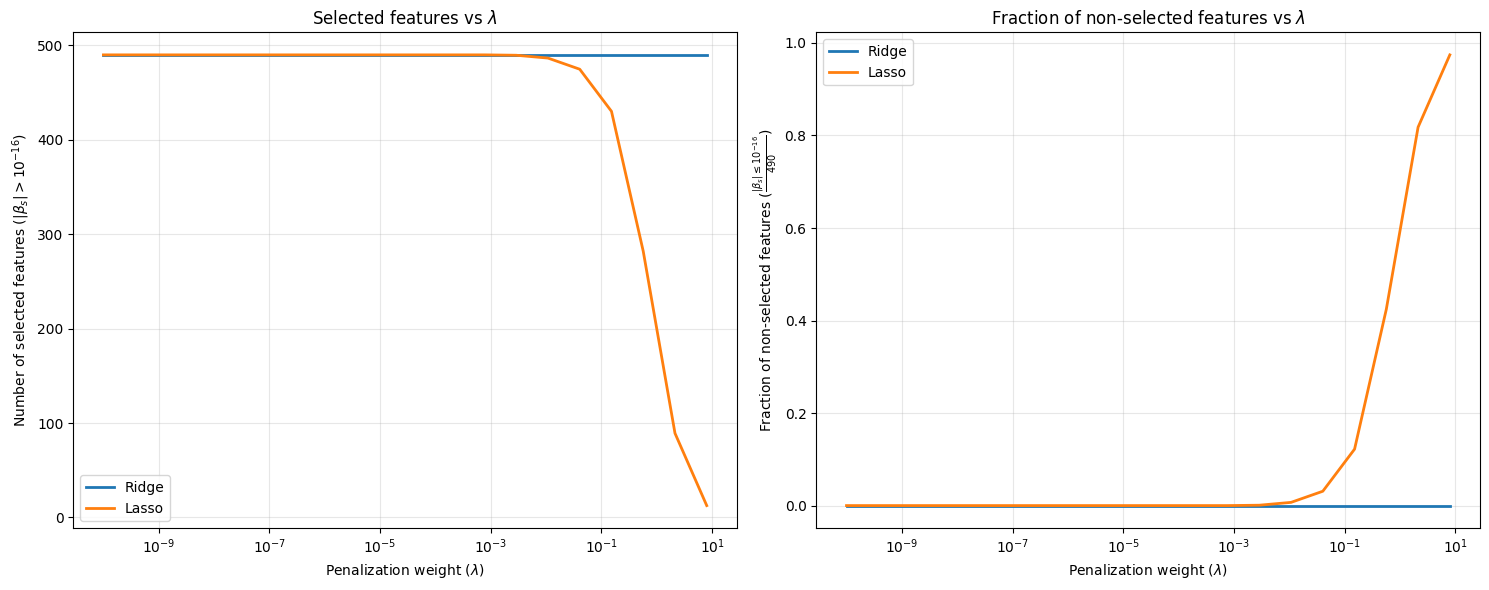

In [100]:
# 6b plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(all_df["lambda"], all_df["ridge_features"], label="Ridge", lw=2)
axes[0].plot(all_df["lambda"], all_df["lasso_features"], label="Lasso", lw=2)
axes[0].set_xscale("log")
axes[0].set_title(r"Selected features vs $\lambda$")
axes[0].set_xlabel(r"Penalization weight ($\lambda$)")
axes[0].set_ylabel(r"Number of selected features ($|\beta_s| > 10^{-16}$)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_df["lambda"], (p - all_df["ridge_features"]) / p, label="Ridge", lw=2)
axes[1].plot(all_df["lambda"], (p - all_df["lasso_features"]) / p, label="Lasso", lw=2)
axes[1].set_xscale("log")
axes[1].set_title(r"Fraction of non-selected features vs $\lambda$")
axes[1].set_xlabel(r"Penalization weight ($\lambda$)")
axes[1].set_ylabel(rf"Fraction of non-selected features ($\frac{{|\beta_s| \leq 10^{{-16}}}}{{{p}}}$)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig("q6b.png", dpi=200, bbox_inches="tight")